# XGBoost Modeling

This notebook trains and evaluates an XGBoost model for predicting tract-level urban opportunity scores.

It includes:
- Dataset loading and cleaning
- Feature scaling
- Model training and evaluation
- Feature importance analysis
- Prediction visualization

Output:
- Trained XGBoost model
- Performance metrics
- Spatial prediction analysis

## Config

In [4]:
NAME = "New York City"

TARGET_VARIABLE = "urban_opportunity_index"

MODEL_FEATURES = [
    "total_population",
    "population_density",
    "median_income",
    "pct_under_18",
    "pct_over_65",
    "pct_bachelors_degree",
    "employment_rate",
    "poverty_rate",
    "road_density",
    "intersection_density",
    "transit_stop_density",
]

## Imports

In [5]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import xgboost as xgb

## Load dataframe

In [6]:
NAME_FILE = NAME.strip().lower().replace(" ", "_")
df = pd.read_parquet(f"../data/{NAME_FILE}_tract_dataset.parquet")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (2327, 13)
Columns: ['GEOID', 'total_population', 'median_income', 'population_density', 'pct_under_18', 'pct_over_65', 'pct_bachelors_degree', 'employment_rate', 'poverty_rate', 'road_density', 'intersection_density', 'transit_stop_density', 'urban_opportunity_index']


## Clean Dataset

In [7]:
def clean_data(df):

    df = df.copy()

    df = df.replace([np.inf, -np.inf], np.nan)

    df = df.dropna(subset=MODEL_FEATURES + [TARGET_VARIABLE])

    df = df[df["total_population"] > 0]

    print("Clean shape:", df.shape)

    return df


df = clean_data(df)

Clean shape: (2201, 13)


## Train Test Split

In [8]:
X = df[MODEL_FEATURES]
y = df[TARGET_VARIABLE]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Training

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
model = xgb.XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_scaled, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

## Results

In [11]:
pred = model.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("RMSE:", round(rmse, 4))
print("R²:", round(r2, 4))

RMSE: 10.8133
R²: 0.4897


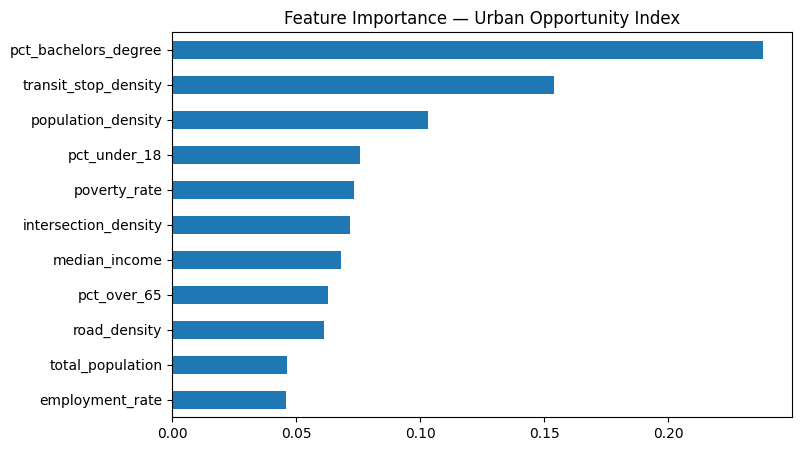

In [12]:
importances = pd.Series(
    model.feature_importances_,
    index=MODEL_FEATURES
).sort_values()

importances.plot.barh(figsize=(8, 5))
plt.title("Feature Importance — Urban Opportunity Index")
plt.show()

In [13]:
df["prediction"] = model.predict(
    scaler.transform(df[MODEL_FEATURES])
)

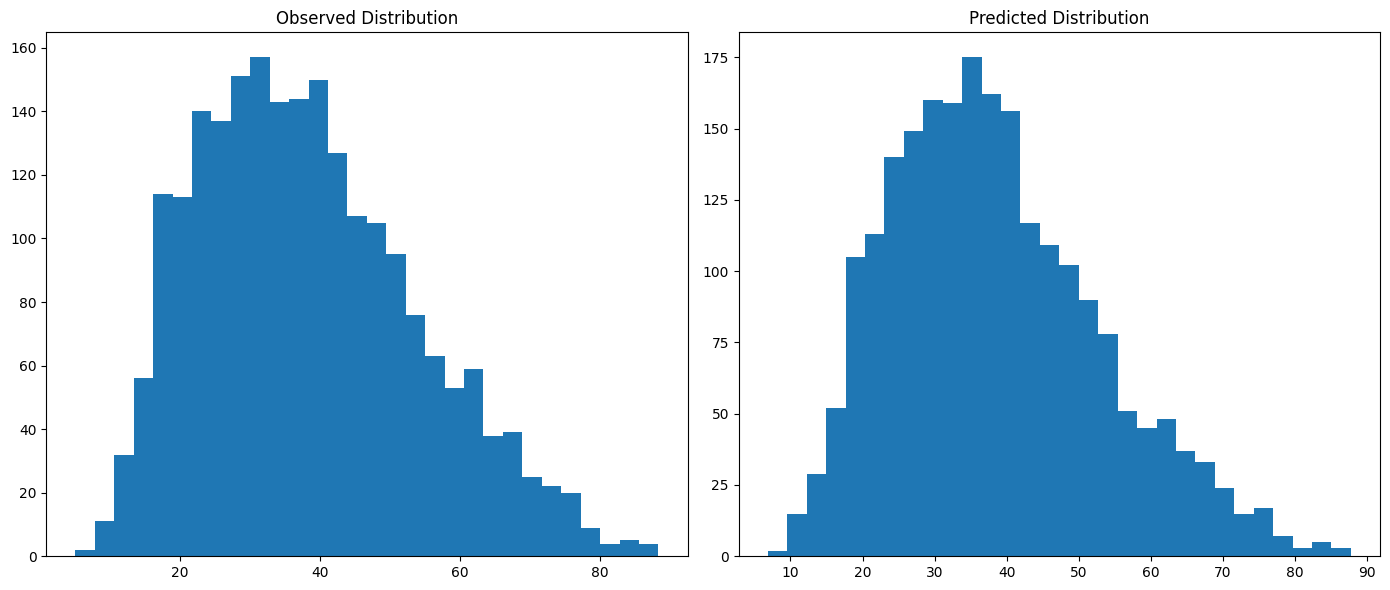

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(df[TARGET_VARIABLE], df[TARGET_VARIABLE], alpha=0)  # placeholder removed below

axes[0].hist(df[TARGET_VARIABLE], bins=30)
axes[0].set_title("Observed Distribution")

axes[1].hist(df["prediction"], bins=30)
axes[1].set_title("Predicted Distribution")

plt.tight_layout()
plt.show()

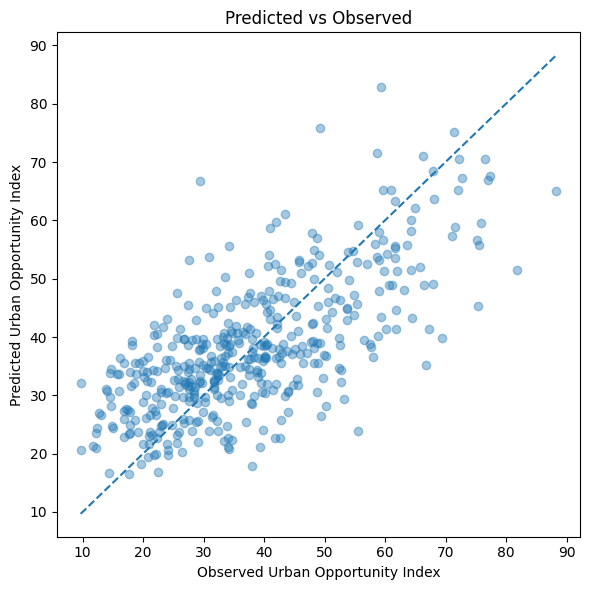

In [15]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(y_test, pred, alpha=0.4)

min_val = min(y_test.min(), pred.min())
max_val = max(y_test.max(), pred.max())

ax.plot([min_val, max_val], [min_val, max_val], linestyle="--")

ax.set_xlabel("Observed Urban Opportunity Index")
ax.set_ylabel("Predicted Urban Opportunity Index")
ax.set_title("Predicted vs Observed")

plt.tight_layout()
plt.show()